# ⚽ Real-World Data Challenge
## FIFA 19 — What Makes a Top Football Player?
### ⏱️ Time Allowed: 2 – 2.5 Hours &nbsp;|&nbsp; Open: Syntax Sheet &nbsp;|&nbsp; Closed: Internet

---

> **The Story:**
> EA Sports collected detailed data on **18,000+ real professional footballers** for FIFA 19.
> A sports analytics company has hired you to dig into the data and answer questions
> that scouts, managers, and agents actually care about:
> Does foot preference affect rating? Do forwards outperform defenders?
> What best predicts a player's market value?
>
> Your job: **explore, test, visualise, and brief the scouting team.**

---

### 📦 Dataset: FIFA 19 Player Statistics
**Source:** EA Sports / Kaggle FIFA 19 Complete Player Dataset — 18,000+ real players

| Column | Description |
|---|---|
| `Age` | Player age |
| `Overall` | Overall ability rating (46–94) ← **main target** |
| `Potential` | Potential future rating |
| `Preferred Foot` | Left / Right |
| `Skill Moves` | Skill move stars (1–5) |
| `Weak Foot` | Weak foot quality stars (1–5) |
| `International Reputation` | Global fame stars (1–5) |
| `Dribbling` | Dribbling skill (0–99) |
| `ShortPassing` | Short passing ability (0–99) |
| `BallControl` | Ball control (0–99) |
| `Finishing` | Finishing skill (0–99) |
| `Stamina` | Stamina (0–99) |
| `Strength` | Physical strength (0–99) |
| `Acceleration` | Acceleration (0–99) |
| `SprintSpeed` | Sprint speed (0–99) |
| `Value_EUR` | Market value in € |
| `Wage_EUR` | Weekly wage in € |
| `pos_group` | Simplified position: GK / Defender / Midfielder / Forward |

---

### 🧭 Challenge Map

| Task | Topic | Est. Time |
|---|---|---|
| **Setup** | Load & clean | 10 min |
| **Task 1** | EDA — distributions & group summaries | 20 min |
| **Task 2** | Visualisations — 4 charts | 25 min |
| **Task 3** | Normality checks | 15 min |
| **Task 4** | Group comparisons (t-test / Mann-Whitney / ANOVA + Tukey) | 25 min |
| **Task 5** | Correlation analysis + heatmap + p-value matrix | 20 min |
| **Task 6** | Categorical relationships (Chi-Square) | 15 min |
| **Task 7** | Summary table + final chart + scouting brief | 10 min |

---
```
p ≤ 0.05  →  Reject H₀   (something real is happening)
p > 0.05  →  Keep H₀     (could be random chance)
```


---
## ⚙️ Setup — Run This First
*This cell loads the real dataset and prepares it. Do not change it.*

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats #contains statistical test and calculations
from statsmodels.stats.multicomp import pairwise_tukeyhsd # use to find which grp is significantly diff from others after ANOVA

# ── Load raw FIFA 19 data ────────────────────────────────────────────────────
url = ("https://raw.githubusercontent.com/amanthedorkknight/"
       "fifa18-all-player-statistics/master/2019/data.csv")
raw = pd.read_csv(url)   # reading csv file and converting that in pandas dataframe original dataset

# ── Clean Value and Wage (convert "€110.5M" → 110500000) ──────────────────── # fifa dataset doesnt store money as normal no. so we convert them in actual numerical numbers
def parse_money(s):     # s is value we want to change
    if pd.isna(s): return np.nan  # check whether value is missing or not
    s = str(s).replace('€', '').strip() # str - convert value to string, remove symbol and remove spaces
    if 'M' in s: return float(s.replace('M', '')) * 1_000_000 # M is million replace it with numerical value
    if 'K' in s: return float(s.replace('K', '')) * 1_000
    try:    return float(s) #handles values that doesnt have M or K
    except: return np.nan

# creates new column containing cleaned values
raw['Value_EUR'] = raw['Value'].apply(parse_money) # gets Value original col and apply this function to every value in that column
raw['Wage_EUR']  = raw['Wage'].apply(parse_money)  # we preserved the original columns and created cleaned numerical col for analysis

# ── Simplify position into 4 groups ─────────────────────────────────────────
def pos_group(p): # fifa has many diff positions so we create broad grps
    if pd.isna(p): return None
    p = str(p).upper() # convert position to text and makes str uppercase
    if 'GK' in p: return 'GK'
    if any(x in p for x in ['CB','LB','RB','LWB','RWB','LCB','RCB']): return 'Defender' # any position (atleast one) matches defender position
    if any(x in p for x in ['CM','CDM','CAM','LM','RM','LAM','RAM','LCM','RCM','LDM','RDM']): return 'Midfielder'
    if any(x in p for x in ['ST','CF','LW','RW','LF','RF','LS','RS']): return 'Forward'
    return None

raw['pos_group'] = raw['Position'].apply(pos_group) # created new col and applied our function

# ── Keep only useful columns, drop rows with key missing values ────────────── # fifa dataset containes many cols so we created list containing relevant columns
cols = ['Name', 'Age', 'Nationality', 'Overall', 'Potential',
        'Preferred Foot', 'Skill Moves', 'Weak Foot',
        'International Reputation',
        'Dribbling', 'ShortPassing', 'BallControl', 'Finishing',
        'Stamina', 'Strength', 'Acceleration', 'SprintSpeed',
        'Value_EUR', 'Wage_EUR', 'pos_group']

df = (raw[cols] # takes only columnss we put in cols list
      .dropna(subset=['Overall', 'Age', 'Preferred Foot', 'pos_group']) # remove rows containing missing values in only these cols
      .query("pos_group in ['GK', 'Defender', 'Midfielder', 'Forward']") # only keeps playesr whose position grp in one of we created
      .reset_index(drop=True)) # reset index and dont keep old index

print("✅ Dataset ready!")
print(f"   Players : {len(df):,}")
print(f"   Columns : {df.shape[1]}")
print()
print(df['pos_group'].value_counts().to_string()) # count players in each position category
df.head()


✅ Dataset ready!
   Players : 18,147
   Columns : 20

pos_group
Midfielder    6838
Defender      5866
Forward       3418
GK            2025


,Name,Age,Nationality,Overall,Potential,Preferred Foot,Skill Moves,Weak Foot,International Reputation,Dribbling,ShortPassing,BallControl,Finishing,Stamina,Strength,Acceleration,SprintSpeed,Value_EUR,Wage_EUR,pos_group
0,L. Messi,31,Argentina,94,94,Left,4.0,4.0,5.0,97.0,90.0,96.0,95.0,72.0,59.0,91.0,86.0,110500000.0,565000.0,Forward
1,Cristiano Ronaldo,33,Portugal,94,94,Right,5.0,4.0,5.0,88.0,81.0,94.0,94.0,88.0,79.0,89.0,91.0,77000000.0,405000.0,Forward
2,Neymar Jr,26,Brazil,92,93,Right,5.0,5.0,5.0,96.0,84.0,95.0,87.0,81.0,49.0,94.0,90.0,118500000.0,290000.0,Forward
3,De Gea,27,Spain,91,93,Right,1.0,3.0,4.0,18.0,50.0,42.0,13.0,43.0,64.0,57.0,58.0,72000000.0,260000.0,GK
4,K. De Bruyne,27,Belgium,91,92,Right,4.0,5.0,4.0,86.0,92.0,91.0,82.0,90.0,75.0,78.0,76.0,102000000.0,355000.0,Midfielder


---
## 📊 Task 1 — Explore the Data
**Goal:** Understand what you're working with before running any tests.

---

### 1a. Basic Inspection

Write code to answer:
1. How many players and columns are in `df`?
2. Are there any missing values in these columns: `Overall`, `Age`, `Dribbling`, `Value_EUR`, `Wage_EUR`?
3. What is the average, minimum, and maximum **Overall** rating?
4. How many players are in each **position group** (`pos_group`)?

💡 **Hints:** `.shape` · `.isnull().sum()` · `.describe()` · `.value_counts()`


In [23]:
# 1a — Basic Inspection

# 1
print('1. Dataset Shape')
print('No. of Players: ', df.shape[0])
print('No. of columns: ', df.shape[1])
print()

# 2
print('2. Missing values')
print(df[['Overall', 'Age', 'Dribbling', 'Value_EUR', 'Wage_EUR']].isnull().sum())
print()

# 3
print('3. Overall Rating Summary')
print('Overall rating: ', df['Overall'].describe())
print()

# 4
print('4. Players in each position group')
print('Players in each grp: ',df['pos_group'].value_counts())



1. Dataset Shape
No. of Players:  18147
No. of columns:  20

2. Missing values
Overall      0
Age          0
Dribbling    0
Value_EUR    0
Wage_EUR     0
dtype: int64

3. Overall Rating Summary
Overall rating:  count    18147.000000
mean        66.253926
std          6.913320
min         46.000000
25%         62.000000
50%         66.000000
75%         71.000000
max         94.000000
Name: Overall, dtype: float64

4. Players in each position group
Players in each grp:  pos_group
Midfielder    6838
Defender      5866
Forward       3418
GK            2025
Name: count, dtype: int64


---
### 1b. Group Summaries

Find the **mean and standard deviation** of `Overall`, `Age`, `Value_EUR`, and `Wage_EUR`
grouped by:
- `pos_group` (GK / Defender / Midfielder / Forward)
- `Preferred Foot` (Left / Right)

💡 **Hint:** `df.groupby('col')[['Overall','Age']].agg(['mean','std']).round(2)`


In [24]:
# 1b — Group summaries by position

# pos_grp -- grp players by position we did already and for each grp calculate given columns mean and std
pos_summary = df.groupby('pos_group')[['Overall', 'Age', 'Value_EUR', 'Wage_EUR']].agg(['mean', 'std']).round(2)
display(pos_summary) # display result as table


Overall          Age         Value_EUR              Wage_EUR  \
              mean   std   mean   std        mean         std      mean   
pos_group                                                                 
Defender     66.40  6.46  25.47  4.52  1975138.08  4106420.51   9146.10   
Forward      66.40  7.02  24.66  4.61  2984155.94  7395815.54  11718.26   
GK           64.60  7.60  26.04  5.47  1585814.81  4562890.61   6803.95   
Midfielder   66.55  6.96  24.78  4.51  2760639.08  5890612.59  10180.61   

                      
                 std  
pos_group             
Defender    18970.31  
Forward     28662.56  
GK          16719.63  
Midfielder  21932.88

In [25]:
# Group summaries by Preferred Foot

# preferred foot -- create two grps left right and calculates mean and std for columns we want to analyze
foot_summary = df.groupby('Preferred Foot')[['Overall', 'Age', 'Value_EUR', 'Wage_EUR']].agg(['mean', 'std']).round(2)
display(foot_summary)


Overall          Age         Value_EUR              Wage_EUR  \
                  mean   std   mean   std        mean         std      mean   
Preferred Foot                                                                
Left             66.80  6.56  25.10  4.52  2588727.73  5956115.19  10353.29   
Right            66.09  7.01  25.13  4.71  2366090.90  5490850.79   9579.57   

                          
                     std  
Preferred Foot            
Left            23656.32  
Right           21512.73

---
### 1c. Written Observations ✍️

Fill in the blanks after running your code:

```
1. The dataset has 18147 players and 20 columns.

2. Missing values found in:
   Overall 0 Age 0 Dribbling 0
   Value_EUR 0 Wage_EUR 0

3. Overall rating → Mean: 66.25  Min: 46 Max: 94

4. Position group counts:
   GK: 2025  Defender: 5866  Midfielder: 6838  Forward: 3418

5. Which position group has the highest average Overall? Midfielder

6. Do left-footed or right-footed players have a higher average Overall?
  Left-footed players  by 0.71 rating points.
  
```


---
## 🎨 Task 2 — Visualisations
**Goal:** See the data. Statistics without charts are blind.

---

### 2a. The Big Four — 2×2 Subplot Grid

Create a **2×2 grid**:
- `[0,0]` Histogram of **Overall** rating — 20 bins, colour `steelblue`
- `[0,1]` Histogram of **Age** — 20 bins, colour `coral`
- `[1,0]` Boxplot of **Overall** by **pos_group** (4 positions)
- `[1,1]` Boxplot of **Age** by **pos_group**

Every subplot needs **title, xlabel, ylabel**. Write one `# observation:` comment per plot.

💡 **Hints:**  
`ax.hist(df['Overall'], bins=20, color='steelblue', edgecolor='white')`  
`df.boxplot(column='Overall', by='pos_group', ax=axes[1,0])`  
`plt.suptitle(...)` · `plt.tight_layout()`


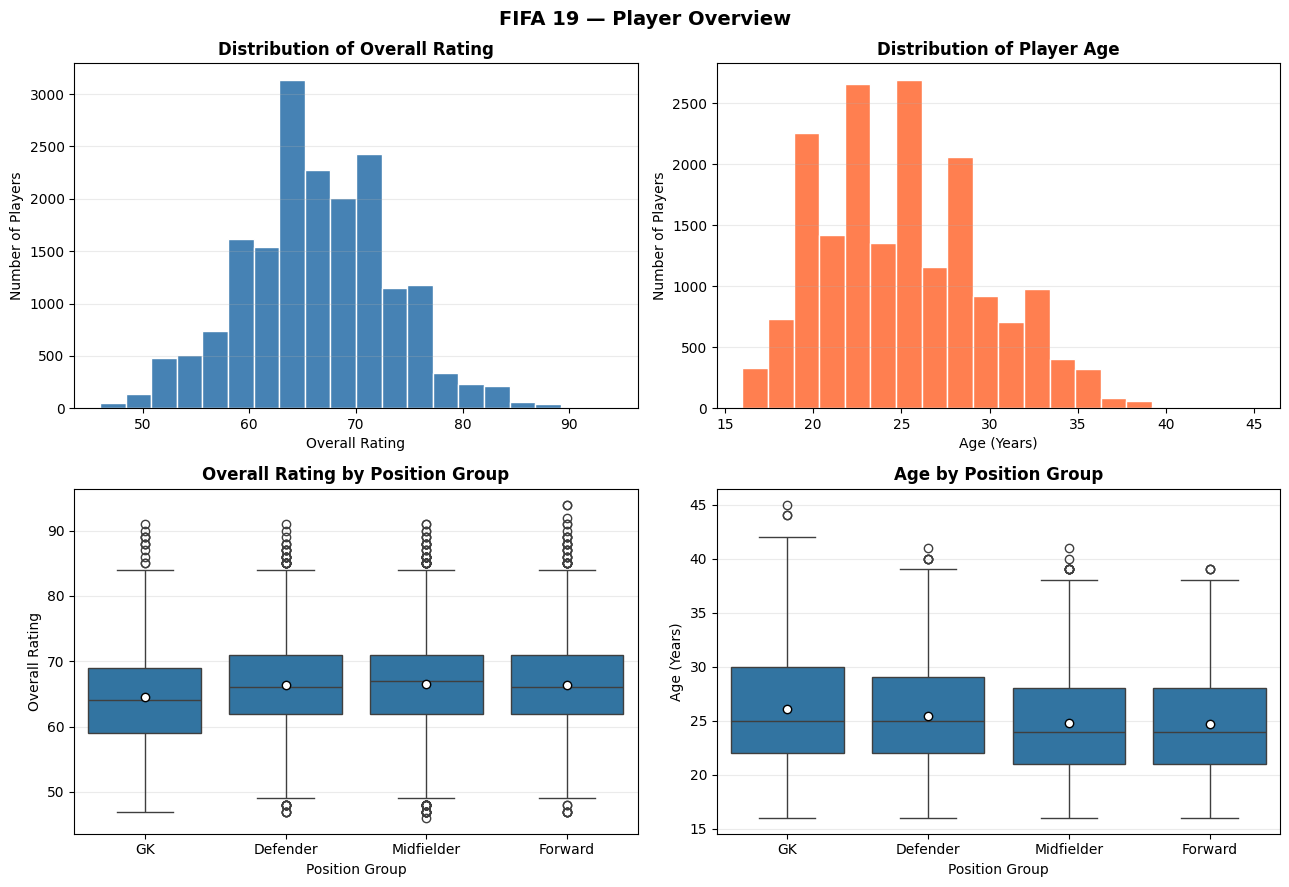

In [26]:
# ── Task 2a: The Big Four — 2×2 Subplot Grid ────────────────────────────────

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
position_order = ['GK', 'Defender', 'Midfielder', 'Forward'] # -- show grps in this order

# [0,0] Histogram of Overall rating -- top-left (histogram shows distribution of numerical data)
axes[0,0].hist(df['Overall'],bins=20,color='steelblue',edgecolor='white')
axes[0,0].set_title('Distribution of Overall Rating', fontweight='bold')
axes[0,0].set_xlabel('Overall Rating')
axes[0,0].set_ylabel('Number of Players')
axes[0,0].grid(axis='y', alpha=0.25)
# observation: Most players have Overall ratings around the mid-60s,
# with relatively few players at the extreme high and low ratings.


# [0,1] Histogram of Age
axes[0,1].hist(df['Age'],bins=20,color='coral',edgecolor='white')
axes[0,1].set_title('Distribution of Player Age', fontweight='bold')
axes[0,1].set_xlabel('Age (Years)')
axes[0,1].set_ylabel('Number of Players')
axes[0,1].grid(axis='y', alpha=0.25)
# observation: Most players are concentrated in their 20s,
# with fewer players appearing at older ages.


# [1,0] Boxplot of Overall by position group -- 2grps comparison use krne k liye like numerical and categorical
sns.boxplot(data=df,x='pos_group',y='Overall',order=position_order,ax=axes[1,0],showmeans=True,meanprops={'marker': 'o','markerfacecolor': 'white','markeredgecolor': 'black'})
axes[1,0].set_title('Overall Rating by Position Group', fontweight='bold')
axes[1,0].set_xlabel('Position Group')
axes[1,0].set_ylabel('Overall Rating')
axes[1,0].grid(axis='y', alpha=0.25)
# observation: Overall ratings overlap considerably across positions,
# although goalkeepers tend to have a lower central rating.


# [1,1] Boxplot of Age by position group
sns.boxplot(data=df,x='pos_group',y='Age',order=position_order,ax=axes[1,1],showmeans=True,meanprops={'marker': 'o','markerfacecolor': 'white','markeredgecolor': 'black'})
axes[1,1].set_title('Age by Position Group', fontweight='bold')
axes[1,1].set_xlabel('Position Group')
axes[1,1].set_ylabel('Age (Years)')
axes[1,1].grid(axis='y', alpha=0.25)
# observation: Goalkeepers tend to be older than players
# in the other position groups.


plt.suptitle('FIFA 19 — Player Overview', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
### 2b. Scatter Plot — Age vs Overall Rating

Create a scatter plot of **Age** (x) vs **Overall** (y).
- Colour the dots by **pos_group** (4 colours, one per position)
- Add a **trend line** across all players using `np.polyfit`
- Proper title, xlabel, ylabel, legend

💡 **Hints:**  
`sns.scatterplot(data=df, x='Age', y='Overall', hue='pos_group', alpha=0.4, ax=ax)`  
`m, b = np.polyfit(df['Age'], df['Overall'], 1)`  
`x_line = np.linspace(df['Age'].min(), df['Age'].max(), 100)`  
`ax.plot(x_line, m*x_line + b, color='black', linewidth=2, linestyle='--')`

> After plotting — does the trend line go up or down? What does that mean for a player's career?


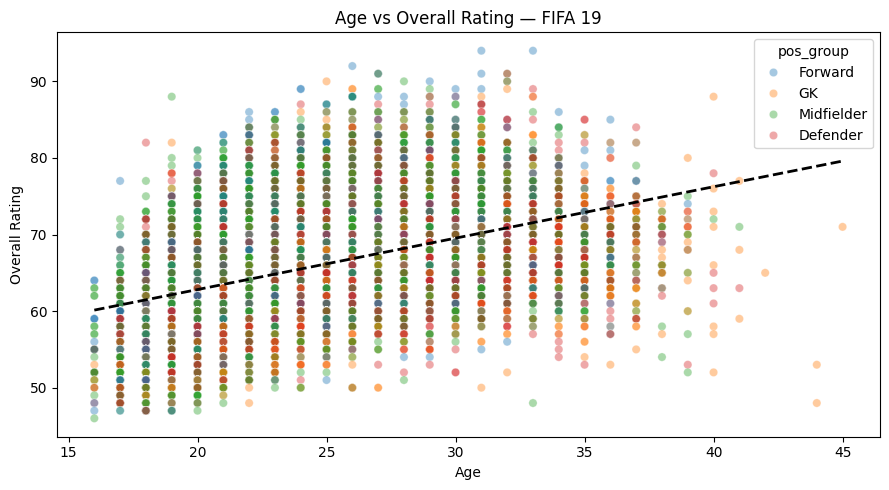

In [27]:
# 2b — Scatter: Age vs Overall
fig, ax = plt.subplots(figsize=(9, 5))

# Scatter plot
sns.scatterplot(data=df,x='Age',y='Overall',hue='pos_group',alpha=0.4,ax=ax) # hue -- diff positions get diff colors

# Trend line across all players np.polyfit -- finds best fitting straight line
m, b = np.polyfit(df['Age'], df['Overall'], 1) # m-slope , b-intercept, 1 means linear trend
x_line = np.linspace(df['Age'].min(), df['Age'].max(), 100) # creates 100 evenly spaced age values
y_line = m * x_line + b # y = mx+b

ax.plot(x_line, y_line, color='black', linewidth=2, linestyle='--', label='Trend Line')

ax.set_title('Age vs Overall Rating — FIFA 19')
ax.set_xlabel('Age')
ax.set_ylabel('Overall Rating')
plt.tight_layout()
plt.show()

# Trend direction: Upward
# What does this suggest about player development? Overall rating tends to increase with age, although this does not mean
# every individual player improves as they get older. there is variation between individual players


scatter plot - overall  relationship
box plot- grp/position difference

---
### 2c. Bar Chart — Average Overall by Position (with Error Bars)

Create a **bar chart** showing the average Overall for each `pos_group`.
- Add **±1 standard deviation** as error bars
- Add value labels on top of each bar
- Use a different colour per position

💡 **Hints:**
```python
grouped = df.groupby('pos_group')['Overall'].agg(['mean','std']).reset_index()
ax.bar(grouped['pos_group'], grouped['mean'],
       yerr=grouped['std'], capsize=5, color=[...], edgecolor='black')
for bar, m in zip(bars, grouped['mean']):
    ax.text(bar.get_x() + bar.get_width()/2, m + 1, f'{m:.1f}', ha='center')
```


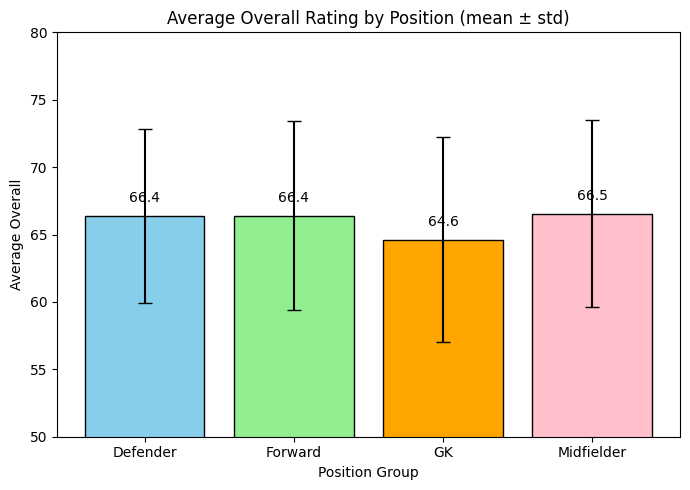

In [28]:
# 2c — Bar Chart: Average Overall by Position
fig, ax = plt.subplots(figsize=(7, 5))

# Group data -- separates players into position grps then take only overall column
grouped = df.groupby('pos_group')['Overall'].agg(['mean', 'std']).reset_index()

# Draw bars with error bars
bars = ax.bar(
    grouped['pos_group'],
    grouped['mean'], # height of each bar
    yerr=grouped['std'], # adds error bars - shows spread variations of overall rating avg
    capsize=5, # small horizontal line at end of erro bars
    color=['skyblue', 'lightgreen', 'orange', 'pink'],
    edgecolor='black'
)

# Add value labels on top of each bar -- simply display mean on each bar with 1 decimal place
for bar, m in zip(bars, grouped['mean']):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        m + 1,
        f'{m:.1f}',
        ha='center'
    )

ax.set_title('Average Overall Rating by Position (mean ± std)')
ax.set_xlabel('Position Group')
ax.set_ylabel('Average Overall')
ax.set_ylim(50, 80) # range of y-axis
plt.tight_layout()
plt.show()

# observation: Midfielders have the highest average Overall rating (66.5),
# while goalkeepers have the lowest (64.6). Defenders and forwards have
# almost identical means, and the large overlapping standard deviations
# show substantial variation within all position groups.

# spread tells how diff individual players rating are from avg
# large error bar -- ratings vary from grp avg and small means rating are clustered around avg

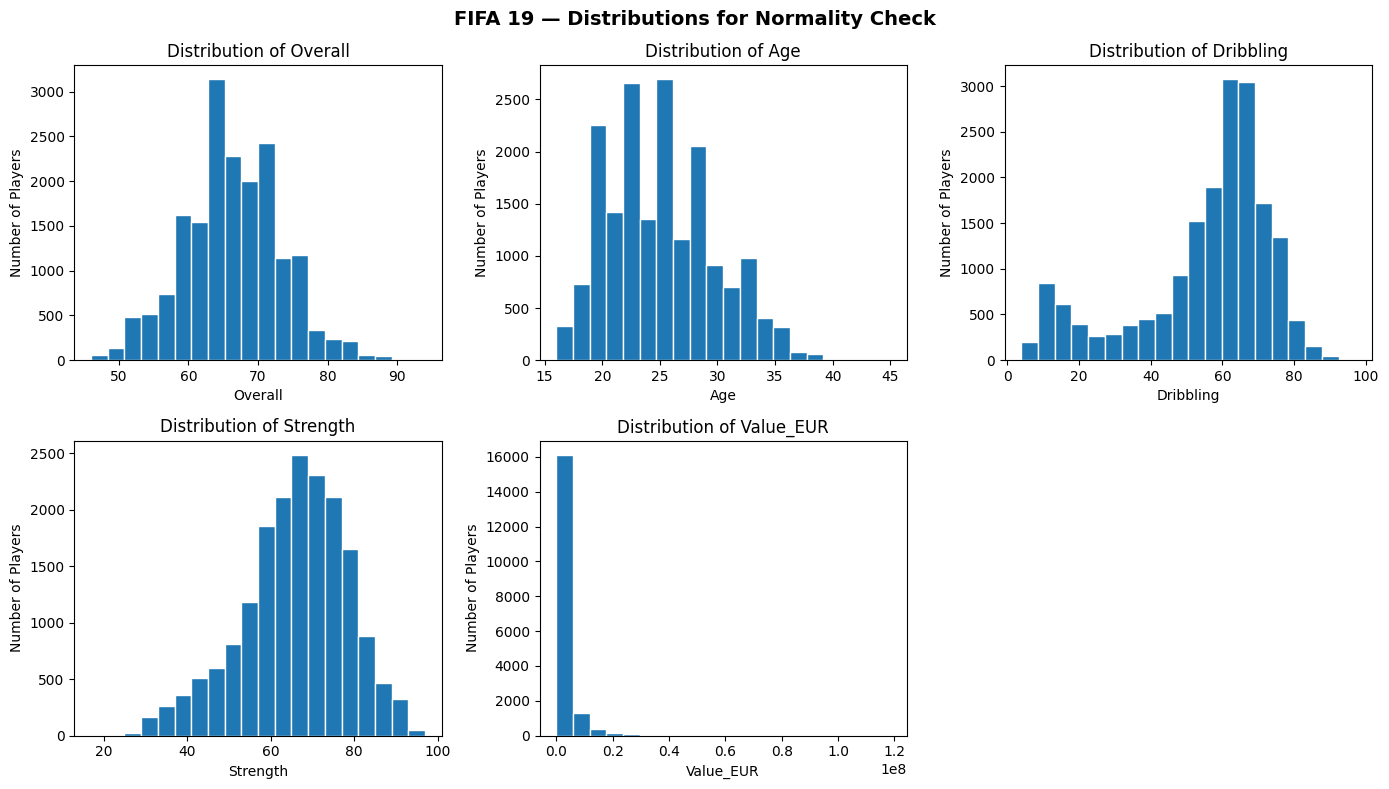

In [29]:
# Histograms for Task 3 — Normality Check

columns_to_test = ['Overall', 'Age', 'Dribbling', 'Strength', 'Value_EUR']

fig, axes = plt.subplots(2, 3, figsize=(14, 8))

for ax, col in zip(axes.flat, columns_to_test):
    ax.hist(df[col], bins=20, edgecolor='white')
    ax.set_title(f'Distribution of {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Number of Players')

# Hide the empty 6th subplot
axes[1, 2].set_visible(False)

plt.suptitle('FIFA 19 — Distributions for Normality Check', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 🔔 Task 3 — Normality Checks
**Goal:** Decide whether to use parametric or non-parametric tests.

---

### 3a. Shapiro-Wilk Test

Run Shapiro-Wilk on: `Overall`, `Age`, `Dribbling`, `Strength`, `Value_EUR`

> ⚠️ **Note:** Shapiro-Wilk is designed for small samples. On large datasets (n > 5000),
> it almost always gives p ≈ 0. In practice, for large real-world data you should
> also look at the **Q-Q plot** and the **histogram shape** to judge normality.
> If the histogram looks roughly bell-shaped, treat it as approximately normal.

Print a clean table with column name, p-value, and your judgement.

💡 **Hints:** `stat, p = stats.shapiro(df['col'].sample(500, random_state=42))` — sample 500 rows for Shapiro


Shapiro-Wilk test is a statistical test used to check whether data is normally distributed or not.
p > 0.05 → data is considered approximately normal

p ≤ 0.05 → data is considered non-normal

In [30]:
# 3a — Shapiro-Wilk (on a 500-row sample per column) # checks whether data look normally distributed or not
columns_to_test = ['Overall', 'Age', 'Dribbling', 'Strength', 'Value_EUR']

print(f"{'Column':<15} {'p-value':>10} {'Normal (p>0.05)?':>18} {'Histogram shape':>16}") # creates a heading and these numbers are just formatting
print("-" * 65)

for col in columns_to_test:
    sample = df[col].dropna().sample(500, random_state=42) # drop missing and randomly take 500 players and make sure u get same players everytime
    stat, p = stats.shapiro(sample)
    normal  = 'Yes' if p > 0.05 else 'No'
    # Add your own shape judgement in the last column: Bell / Skewed / Other
    shapes = {
   'Overall': 'Approx. Bell',
    'Age': 'Right-Skewed',
    'Dribbling': 'Bimodal / Irregular',
    'Strength': 'Approx. Bell',
    'Value_EUR': 'Strong Right-Skew'
    }
    shape = shapes[col]   # ← replace with your observation after looking at histograms
    print(f"{col:<15} {p:>10.4f} {normal:>18} {shape:>16}")


Column             p-value   Normal (p>0.05)?  Histogram shape
-----------------------------------------------------------------
Overall             0.0165                 No     Approx. Bell
Age                 0.0000                 No     Right-Skewed
Dribbling           0.0000                 No Bimodal / Irregular
Strength            0.0000                 No     Approx. Bell
Value_EUR           0.0000                 No Strong Right-Skew


---
### 3b. Q-Q Plots

Create a **1×5 grid of Q-Q plots** for the same five columns.
- Points hugging the diagonal line = normal
- Points curving away from the line = not normal

💡 **Hint:** `stats.probplot(df['col'].dropna(), plot=axes[i])`


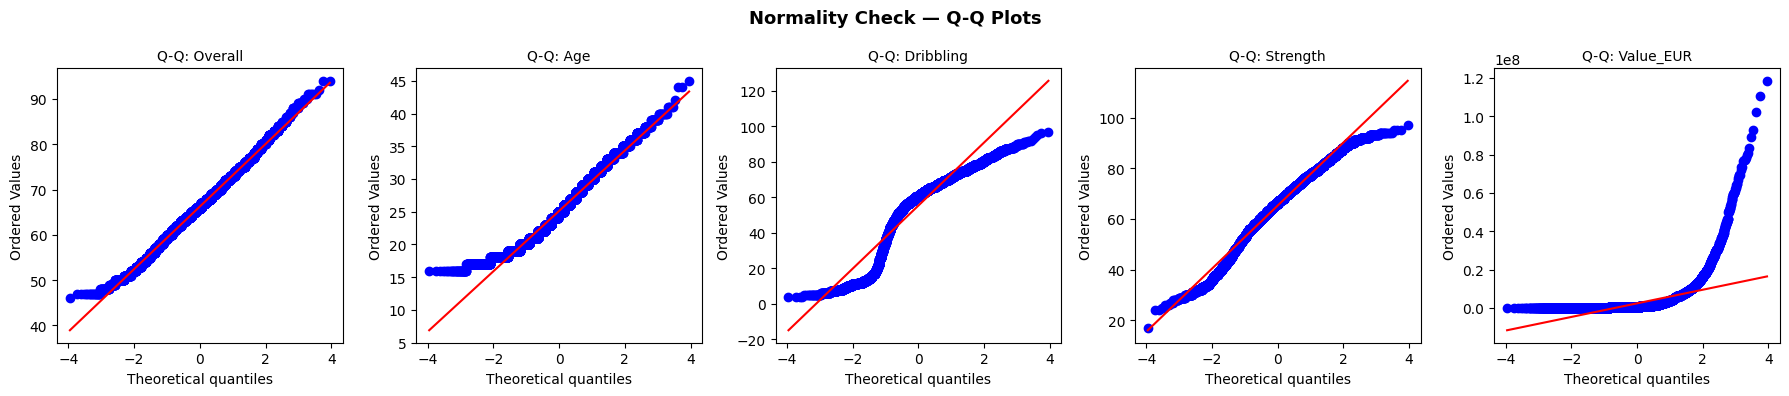

In [31]:
# 3b — Q-Q Plots -- quantile quantile plot check whether data is normally distributed or not visually
fig, axes = plt.subplots(1, 5, figsize=(18, 4))

for i, col in enumerate(['Overall', 'Age', 'Dribbling', 'Strength', 'Value_EUR']):
    stats.probplot(df[col].dropna(), plot=axes[i]) # create prob plot
    axes[i].set_title(f'Q-Q: {col}', fontsize=10) # gives each plot its column name

plt.suptitle('Normality Check — Q-Q Plots', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


   Age   Log_Age  Dribbling  Log_Dribbling    Value_EUR  Log_Value_EUR
0   31  3.465736       97.0       4.584967  110500000.0      18.520526
1   33  3.526361       88.0       4.488636   77000000.0      18.159316
2   26  3.295837       96.0       4.574711  118500000.0      18.590424
3   27  3.332205       18.0       2.944439   72000000.0      18.092177
4   27  3.332205       86.0       4.465908  102000000.0      18.440483


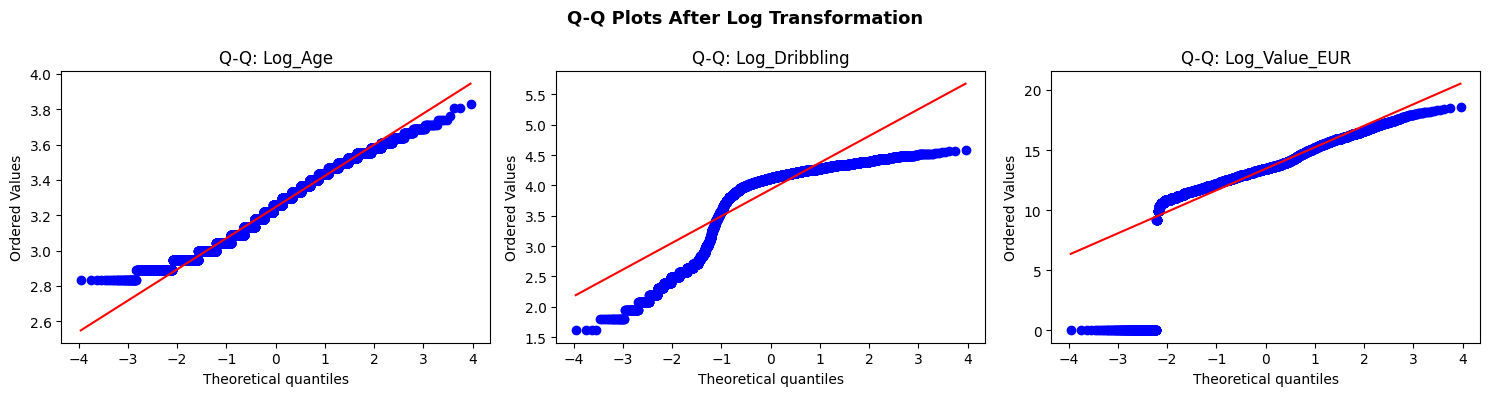

In [32]:
# Log transformation for non-normal variables

df['Log_Age'] = np.log1p(df['Age']) # we used log1p bcz it works safely even when value is 0
df['Log_Dribbling'] = np.log1p(df['Dribbling'])
df['Log_Value_EUR'] = np.log1p(df['Value_EUR'])

print(df[['Age', 'Log_Age',
          'Dribbling', 'Log_Dribbling',
          'Value_EUR', 'Log_Value_EUR']].head())
# Q-Q plots after log transformation

log_columns = ['Log_Age', 'Log_Dribbling', 'Log_Value_EUR']
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, col in enumerate(log_columns):
    stats.probplot(df[col].dropna(), plot=axes[i]) # checks whether each log-transformed var is closer to normal distribution
    axes[i].set_title(f'Q-Q: {col}')

plt.suptitle(
    'Q-Q Plots After Log Transformation',
    fontsize=13,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

---
### 3c. Your Decision Table ✍️

Fill this in — it determines which tests you use in Tasks 4 and 5:

| Column | Histogram Shape | Q-Q Shape | Treat as Normal? | → Use for groups | → Use for relationship |
|---|---|---|---|---|---|
| Overall | Bell |follows line, slight tail deviation | Yes - approx | t-test / Mann-Whitney | Pearson / Spearman |
| Age |Right-skewed | log closer to line but slight deviation | No | Mann-Whiteny | Spearman |
| Dribbling | Bimodal / Irregular | S-shaped deviation | No | Mann-Whiteny | Spearman |
| Strength | Approx Bell | Linear in centre, tail deviation | Yes | t-test / ANoVA | Pearson |
| Value_EUR | reduced right-skewed | log value closer to line | Yes | t-test/ANOVA | Pearson |

> 💡 If ANY group in a comparison is non-normal → use non-parametric.


---
## 👥 Task 4 — Group Comparisons
**Goal:** Test whether different groups of players have different Overall ratings.

---

### 4a. Do Left-Footed vs Right-Footed Players Differ in Overall?

**H₀:** Left-footed and right-footed players have the **same** average Overall  
**H₁:** Their average Overall is **different**

Steps:
1. Extract Overall for each foot group
2. Check normality of each group (Shapiro — sample 500)
3. Based on normality → choose **t-test** or **Mann-Whitney U**
4. Run the test, print statistic, p-value, verdict

💡 **Hints:**  
`left  = df[df['Preferred Foot'] == 'Left']['Overall']`  
`stats.ttest_ind(left, right)` or `stats.mannwhitneyu(left, right, alternative='two-sided')`


In [33]:
# 4a — Left-Footed vs Right-Footed: Overall Rating

left  = df[df['Preferred Foot'] == 'Left']['Overall'] # find players with left foot then take only overall ratings
right = df[df['Preferred Foot'] == 'Right']['Overall']

print(f"Left foot  — mean: {left.mean():.2f}  std: {left.std():.2f}  n: {len(left)}")
print(f"Right foot — mean: {right.mean():.2f}  std: {right.std():.2f}  n: {len(right)}")
print()

# H₀: Left-footed and right-footed players have the same Overall rating.
# H₁: Left-footed and right-footed players have different Overall ratings.


# Step 2: Normality check (sample 500 each) -- checks data look normally distributed or not
stat_left, p_left = stats.shapiro(left.sample(500, random_state=42))
stat_right, p_right = stats.shapiro(right.sample(500, random_state=42))

print(f"Shapiro Left  — p-value: {p_left:.4f}")
print(f"Shapiro Right — p-value: {p_right:.4f}")
print()


# Step 3 & 4: Run chosen test and print verdict
if p_left > 0.05 and p_right > 0.05:
    test_stat, p_value = stats.ttest_ind(left, right) # Used to compare the means of two independent groups
    print("Test used: Independent t-test")
    print(f"t-statistic: {test_stat:.4f}")
else:

    # At least one group is non-normal → Mann-Whitney U test
    test_stat, p_value = stats.mannwhitneyu( # It's the non-parametric alternative used here when the normality condition isn't met.
        left,
        right,
        alternative='two-sided'
    )
    print("Test used: Mann-Whitney U")
    print(f"U-statistic: {test_stat:.4f}")

print(f"p-value: {p_value:.4f}")

# Final decision
if p_value <= 0.05:
    print("Verdict: Reject H₀ — there is a statistically significant difference.")
else:
    print("Verdict: Fail to reject H₀ — no statistically significant difference was found.")



Left foot  — mean: 66.80  std: 6.56  n: 4209
Right foot — mean: 66.09  std: 7.01  n: 13938

Shapiro Left  — p-value: 0.0082
Shapiro Right — p-value: 0.0547

Test used: Mann-Whitney U
U-statistic: 30999381.0000
p-value: 0.0000
Verdict: Reject H₀ — there is a statistically significant difference.


The left-footed players had an average Overall of 66.80, while right-footed players had 66.09. The Shapiro-Wilk test showed that the left-footed group was non-normal, so I used the Mann-Whitney U test. The p-value was below 0.05, so I rejected H₀ and concluded that there is a statistically significant difference in Overall ratings between the two groups.

---
### 4b. Do Forwards Score Higher in Overall than Defenders?

Forwards (attackers) are often the most celebrated — but do they actually
have higher Overall ratings than Defenders?

**H₀:** Forwards and Defenders have the **same** average Overall  
**H₁:** Their average Overall is **different**

Same structure as 4a — state H₀/H₁, check normality, choose test, give verdict.


In [34]:
# 4b — Forwards vs Defenders: Overall Rating

# H₀: Forwards and Defenders have the same average Overall
# H₁: Forwards and Defenders have different average Overall

forwards  = df[df['pos_group'] == 'Forward']['Overall'].dropna()
defenders = df[df['pos_group'] == 'Defender']['Overall'].dropna()

print(f"Forwards  — mean: {forwards.mean():.2f}  std: {forwards.std():.2f}  n: {len(forwards)}")
print(f"Defenders — mean: {defenders.mean():.2f}  std: {defenders.std():.2f}  n: {len(defenders)}")
print()

# Step 2: Normality check (sample 500 each)

stat_forward, p_forward = stats.shapiro(
    forwards.sample(500, random_state=42)
)
stat_defender, p_defender = stats.shapiro(
    defenders.sample(500, random_state=42)
)
print(f"Shapiro Forward  — p-value: {p_forward:.4f}")
print(f"Shapiro Defender — p-value: {p_defender:.4f}")
print()


# Step 3: Choose test
if p_forward > 0.05 and p_defender > 0.05:
    test_stat, p_value = stats.ttest_ind(forwards, defenders)
    print("Test used: Independent t-test")
    print(f"t-statistic: {test_stat:.4f}")

else:
    test_stat, p_value = stats.mannwhitneyu(
        forwards,
        defenders,
        alternative='two-sided'
    )
    print("Test used: Mann-Whitney U")
    print(f"U-statistic: {test_stat:.4f}")

# Step 4: Final verdict
print(f"p-value: {p_value:.4f}")

if p_value <= 0.05:
    print("Verdict: Reject H₀ — there is a statistically significant difference.")
else:
    print("Verdict: Fail to reject H₀ — no statistically significant difference was found.")

Forwards  — mean: 66.40  std: 7.02  n: 3418
Defenders — mean: 66.40  std: 6.46  n: 5866

Shapiro Forward  — p-value: 0.3852
Shapiro Defender — p-value: 0.0464

Test used: Mann-Whitney U
U-statistic: 10019183.5000
p-value: 0.9628
Verdict: Fail to reject H₀ — no statistically significant difference was found.


Forwards and defenders both have an average Overall rating of 66.40. The Forward group was approximately normal, but the Defender group was non-normal, so I used the Mann-Whitney U test. The p-value was 0.9628, which is greater than 0.05, so I failed to reject H₀. There is no statistically significant evidence of a difference in Overall ratings between forwards and defenders in this dataset.

---
### 4c. Do All 4 Position Groups Differ in Overall? → ANOVA / Kruskal-Wallis

**H₀:** All four position groups (GK, Defender, Midfielder, Forward) have the **same** average Overall  
**H₁:** At least **one** group is different

Steps:
1. Build a list of Overall rating arrays — one per position group
2. Check normality on at least 2 groups
3. Run **ANOVA** (if normal) or **Kruskal-Wallis** (if not normal)
4. If p ≤ 0.05 → run **Tukey post-hoc** to find which pairs differ

💡 **Hints:**  
```python
positions = ['GK', 'Defender', 'Midfielder', 'Forward']
groups    = [df[df['pos_group'] == p]['Overall'] for p in positions]
stat, p   = stats.f_oneway(*groups)   # ANOVA
# OR
stat, p   = stats.kruskal(*groups)    # Kruskal-Wallis

# Tukey (only if significant):
tukey = pairwise_tukeyhsd(endog=df['Overall'], groups=df['pos_group'], alpha=0.05)
print(tukey.summary())
```


In [35]:
# 4c — ANOVA / Kruskal-Wallis: Position Group vs Overall

positions = ['GK', 'Defender', 'Midfielder', 'Forward']
groups    = [df[df['pos_group'] == p]['Overall'] for p in positions] # It extracts the Overall ratings separately for each position. list comprehension
# creates 4 separate overall rating lists, p takes each position one by one
print("Group means:")
for pos, g in zip(positions, groups):
    print(f"  {pos:<12}: mean={g.mean():.2f}  std={g.std():.2f}  n={len(g)}")
print()

# Normality check on 2 groups (sample 500)
stat_gk, p_gk = stats.shapiro(
    groups[0].sample(500, random_state=42)
)
stat_def, p_def = stats.shapiro(
    groups[1].sample(500, random_state=42)
)
print(f"Shapiro GK       — p-value: {p_gk:.4f}")
print(f"Shapiro Defender — p-value: {p_def:.4f}")
print()

# Run ANOVA or Kruskal-Wallis -- Are the average Overall ratings of these four groups all the same, or is at least one different
if p_gk > 0.05 and p_def > 0.05:
    # Both checked groups are approximately normal
    stat, p = stats.f_oneway(*groups) # all grps
    print("Test used: One-way ANOVA")
    print(f"F-statistic: {stat:.4f}")

else:
    # At least one checked group is non-normal --  At least one of the two groups we checked was non-normal, so use Kruskal-Wallis.
    stat, p = stats.kruskal(*groups)
    print("Test used: Kruskal-Wallis")
    print(f"H-statistic: {stat:.4f}")

print(f"p-value: {p:.4f}")


# Step 4: Verdict and Tukey post-hoc if significant -- Tukey HSD tells us which specific position pairs have significantly different Overall ratings.
if p <= 0.05:
    print("Verdict: Reject H₀ — at least one position group differs.")
    # Tukey post-hoc test
    tukey = pairwise_tukeyhsd(
        endog=df['Overall'],
        groups=df['pos_group'],
        alpha=0.05
    )
    print()
    print("Tukey HSD post-hoc results:")
    print(tukey.summary())
else:
    print("Verdict: Fail to reject H₀ — no statistically significant difference was found among the position groups.")


Group means:
  GK          : mean=64.60  std=7.60  n=2025
  Defender    : mean=66.40  std=6.46  n=5866
  Midfielder  : mean=66.55  std=6.96  n=6838
  Forward     : mean=66.40  std=7.02  n=3418

Shapiro GK       — p-value: 0.0078
Shapiro Defender — p-value: 0.0464

Test used: Kruskal-Wallis
H-statistic: 131.5085
p-value: 0.0000
Verdict: Reject H₀ — at least one position group differs.

Tukey HSD post-hoc results:
   Multiple Comparison of Means - Tukey HSD, FWER=0.05    
 group1    group2   meandiff p-adj   lower   upper  reject
----------------------------------------------------------
Defender    Forward  -0.0031    1.0 -0.3839  0.3778  False
Defender         GK  -1.7966    0.0 -2.2528 -1.3405   True
Defender Midfielder   0.1457 0.6343 -0.1693  0.4607  False
 Forward         GK  -1.7936    0.0 -2.2899 -1.2972   True
 Forward Midfielder   0.1488 0.7313  -0.222  0.5195  False
      GK Midfielder   1.9423    0.0  1.4945  2.3901   True
-----------------------------------------------------

In [ ]:

# Which pairs are significantly different? (look for reject=True rows)
# GK vs Defender, GK vs Forward, and GK vs Midfielder are significantly different (reject=True).


---
## 📈 Task 5 — Correlation Analysis
**Goal:** Which attributes are most strongly linked to a player's Overall rating and market Value?

---

### 5a. Correlation Heatmap

Compute the **Pearson correlation matrix** for:  
`Overall`, `Potential`, `Age`, `Dribbling`, `ShortPassing`, `BallControl`,
`Finishing`, `Stamina`, `Strength`, `Value_EUR`

Display it as a **heatmap** — use `coolwarm`, annotated, values from -1 to +1.

💡 **Hints:**  
`corr = df[cols].corr()`  
`sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5)`


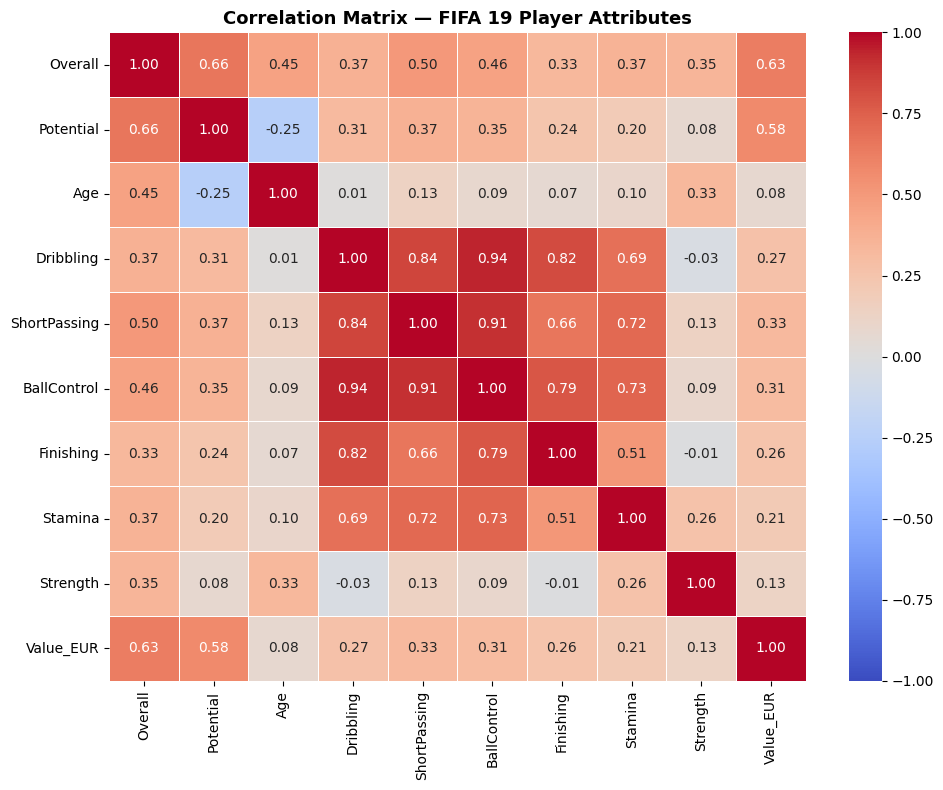

In [36]:
# 5a — Correlation Matrix Heatmap
cols5a = ['Overall', 'Potential', 'Age', 'Dribbling', 'ShortPassing',
          'BallControl', 'Finishing', 'Stamina', 'Strength', 'Value_EUR']

corr = df[cols5a].corr() # selects 10 columns and calculates pearson correlation b/w each pair

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr,
            annot=True, fmt='.2f',
            cmap='coolwarm', vmin=-1, vmax=1,
            linewidths=0.5, ax=ax)
ax.set_title('Correlation Matrix — FIFA 19 Player Attributes', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Which attribute is most positively correlated with Overall?
# Answer: Potential (r = 0.66)

# Which attribute is most negatively correlated with Value_EUR?
# Answer: No negative correlation was found. Age had the weakest relationship (r = 0.08).


---
### 5b. Hypothesis Tests on Three Key Relationships

Test these claims:

**Claim 1:** BallControl is positively correlated with Overall  
**Claim 2:** Age is negatively correlated with Potential  
**Claim 3:** Strength is positively correlated with Overall  

For each:
1. State H₀ and H₁
2. Choose Pearson **or** Spearman (based on Task 3 normality decisions)
3. Run the test → report correlation coefficient (r or ρ), p-value, verdict
4. Write one sentence of plain-English interpretation

💡 **Hints:**  
`r, p = stats.pearsonr(df['BallControl'], df['Overall'])`  
`rho, p = stats.spearmanr(df['Age'], df['Potential'])`


In [37]:
# 5b — Correlation Tests

# ── Claim 1: BallControl vs Overall ─────────────────────────────────────────
# H₀: There is no significant correlation between BallControl and Overall.
# H₁: There is a significant positive correlation between BallControl and Overall.

rho1, p1 = stats.spearmanr(df['BallControl'], df['Overall'])
print("Claim 1: BallControl vs Overall")
print(f"Spearman correlation (ρ): {rho1:.4f}") # corelation coefficient
print(f"p-value: {p1:.4f}") # p value
if p1 <= 0.05:
    print("Verdict: Reject H₀ — there is a statistically significant correlation.")
else:
    print("Verdict: Fail to reject H₀ — no statistically significant correlation was found.")

print()


# ── Claim 2: Age vs Potential ────────────────────────────────────────────────
# H₀: There is no significant correlation between Age and Potential.
# H₁: There is a significant negative correlation between Age and Potential.

rho2, p2 = stats.spearmanr(df['Age'], df['Potential'])
print("Claim 2: Age vs Potential")
print(f"Spearman correlation (ρ): {rho2:.4f}")
print(f"p-value: {p2:.4f}")
if p2 <= 0.05:
    print("Verdict: Reject H₀ — there is a statistically significant correlation.")
else:
    print("Verdict: Fail to reject H₀ — no statistically significant correlation was found.")

print()


# ── Claim 3: Strength vs Overall ────────────────────────────────────────────
# H₀: There is no significant correlation between Strength and Overall.
# H₁: There is a significant positive correlation between Strength and Overall.

rho3, p3 = stats.spearmanr(df['Strength'], df['Overall'])
print("Claim 3: Strength vs Overall")
print(f"Spearman correlation (ρ): {rho3:.4f}")
print(f"p-value: {p1:.3e}")
if p3 <= 0.05:
    print("Verdict: Reject H₀ — there is a statistically significant correlation.")
else:
    print("Verdict: Fail to reject H₀ — no statistically significant correlation was found.")




Claim 1: BallControl vs Overall
Spearman correlation (ρ): 0.6228
p-value: 0.0000
Verdict: Reject H₀ — there is a statistically significant correlation.

Claim 2: Age vs Potential
Spearman correlation (ρ): -0.2623
p-value: 0.0000
Verdict: Reject H₀ — there is a statistically significant correlation.

Claim 3: Strength vs Overall
Spearman correlation (ρ): 0.3526
p-value: 0.000e+00
Verdict: Reject H₀ — there is a statistically significant correlation.


BallControl and Overall have a significant positive correlation (ρ = 0.6228, p < 0.05).

Age and Potential have a significant negative correlation (ρ = −0.2623, p < 0.05).

Strength and Overall have a significant positive correlation (ρ = 0.3526, p < 0.05).

---
### 5c. p-value Matrix — Which Correlations Are Significant? (⭐ Challenge)

Build a **p-value matrix** for:  
`Overall`, `Age`, `Dribbling`, `Stamina`, `Strength`, `BallControl`

Then display a heatmap **masking non-significant pairs** (p > 0.05) — only
show the cells where the relationship is statistically real.

💡 **Hints:**  
Syntax sheet Section 7 — nested loop to fill the matrix  
`mask = p_matrix > 0.05`  
`sns.heatmap(p_matrix, mask=mask, annot=True, fmt='.3f', cmap='Reds_r', vmin=0, vmax=0.05)`


             Overall  Age  Dribbling  Stamina  Strength  BallControl
Overall          1.0  0.0        0.0      0.0       0.0          0.0
Age              0.0  1.0        0.0      0.0       0.0          0.0
Dribbling        0.0  0.0        1.0      0.0       0.0          0.0
Stamina          0.0  0.0        0.0      1.0       0.0          0.0
Strength         0.0  0.0        0.0      0.0       1.0          0.0
BallControl      0.0  0.0        0.0      0.0       0.0          1.0


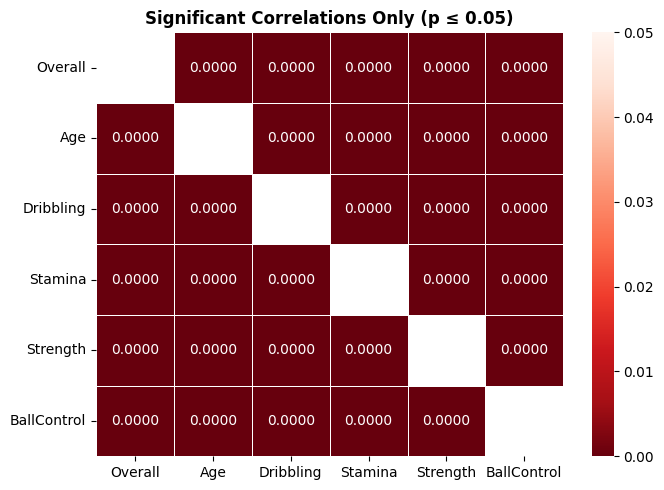

In [38]:
# 5c — p-value Matrix (⭐ Challenge)
cols5c = ['Overall', 'Age', 'Dribbling', 'Stamina', 'Strength', 'BallControl']

p_matrix = pd.DataFrame(np.ones((len(cols5c), len(cols5c))),
                         index=cols5c, columns=cols5c) # create an empty p value table

for c1 in cols5c: # compare evry column with every other column
    for c2 in cols5c:
        if c1 != c2:
            rho, p = stats.spearmanr(df[c1], df[c2]) # gives corelation value and p-value
            p_matrix.loc[c1, c2] = p

print(p_matrix.round(4))
mask = p_matrix > 0.05

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(p_matrix, mask=mask,
            annot=True, fmt='.4f',
            cmap='Reds_r', vmin=0, vmax=0.05,
            linewidths=0.5, ax=ax)
ax.set_title('Significant Correlations Only (p ≤ 0.05)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


Task 5c checks whether the correlations found in Task 5a are statistically real or just happened by chance.

p-value ≤ 0.05 means the relationship is significant (real); p-value > 0.05 means the relationship may be random.


---
## 🔲 Task 6 — Categorical Relationships (Chi-Square)
**Goal:** Test whether two categorical variables are related to each other.

---

### 6a. Is Preferred Foot linked to Position Group?

Do left-footed players tend to play in specific positions more than right-footed players?

**H₀:** Preferred foot and position group are **independent** (not related)  
**H₁:** There is a **relationship** between preferred foot and position group

Steps:
1. Build a crosstab of `Preferred Foot` vs `pos_group`
2. Calculate and display **row percentages**
3. Run Chi-Square test
4. Print verdict

💡 **Hints:**  
`table = pd.crosstab(df['Preferred Foot'], df['pos_group'])`  
`row_pct = table.div(table.sum(axis=1), axis=0).round(2)`  
`chi2, p, dof, expected = stats.chi2_contingency(table)`


In [44]:
# 6a — Preferred Foot vs Position Group

# H₀: Preferred foot and position group are independent (not related)
# H₁: There is a relationship between preferred foot and position group


# Crosstab (counts)
table = pd.crosstab(df['Preferred Foot'], df['pos_group'])
print("Frequency Table:")
print(table)
print()

# Row percentages -- converst counts into percentages within each foot grp
row_pct = table.div(table.sum(axis=1), axis=0).round(2)
print("Row Percentages:")
print(row_pct)
print()


# Chi-Square test -- tests whether psoition grp and preferred foot are related or not
chi2, p, dof, expected = stats.chi2_contingency(table)
print(f"Chi-square statistic: {chi2:.4f}")
print(f"p-value: {p:.3e}")
print(f"Degrees of freedom: {dof}")
print()

# Verdict & Interpretation:
if p <= 0.05:
    print("Verdict: Reject H₀ — Preferred Foot and Position Group are significantly related.")
else:
    print("Verdict: Fail to reject H₀ — no significant relationship was found.")


Frequency Table:
pos_group       Defender  Forward    GK  Midfielder
Preferred Foot                                     
Left                1884      596   206        1523
Right               3982     2822  1819        5315

Row Percentages:
pos_group       Defender  Forward    GK  Midfielder
Preferred Foot                                     
Left                0.45     0.14  0.05        0.36
Right               0.29     0.20  0.13        0.38

Chi-square statistic: 521.7735
p-value: 9.117e-113
Degrees of freedom: 3

Verdict: Reject H₀ — Preferred Foot and Position Group are significantly related.


---
### 6b. Is Skill Moves Level Linked to Position Group?

Skill Moves range from 1–5 stars. Players with 4–5 stars are elite dribblers.
Create a new column `skill_tier`: **'High'** (Skill Moves ≥ 4) vs **'Low'** (Skill Moves < 4).

Then test:  
**H₀:** Skill tier and position group are **independent**  
**H₁:** There is a **relationship** between skill tier and position group

Full solution — no starter code. State H₀/H₁, build crosstab, show row %, run Chi-Square, give verdict.


In [45]:
# 6b — Skill Tier vs Position Group

# Create skill_tier column
df['skill_tier'] = np.where( # works like an if-else
    df['Skill Moves'] >= 4,
    'High',
    'Low'
)

# H₀: Skill tier and position group are independent
# H₁: There is a relationship between skill tier and position group

# Crosstab (counts)
table = pd.crosstab(df['skill_tier'], df['pos_group'])
print("Frequency Table:")
print(table)
print()

# Row percentages
row_pct = table.div(table.sum(axis=1), axis=0).round(2)
print("Row Percentages:")
print(row_pct)
print()

# Chi-Square test
chi2, p, dof, expected = stats.chi2_contingency(table)
print(f"Chi-square statistic: {chi2:.4f}")
print(f"p-value: {p:.3e}")
print(f"Degrees of freedom: {dof}")
print()

# Verdict
if p <= 0.05:
    print("Verdict: Reject H₀ — Skill Tier and Position Group are significantly related.")
else:
    print("Verdict: Fail to reject H₀ — no significant relationship was found.")

Frequency Table:
pos_group   Defender  Forward    GK  Midfielder
skill_tier                                     
High              48      312     0         608
Low             5818     3106  2025        6230

Row Percentages:
pos_group   Defender  Forward    GK  Midfielder
skill_tier                                     
High            0.05     0.32  0.00        0.63
Low             0.34     0.18  0.12        0.36

Chi-square statistic: 619.7948
p-value: 5.153e-134
Degrees of freedom: 3

Verdict: Reject H₀ — Skill Tier and Position Group are significantly related.


---
### 6c. Visualise the Crosstabs

Create a **1×2 grid of stacked bar charts**:
- Left: **Preferred Foot** vs pos_group (row proportions)
- Right: **Skill Tier** vs pos_group (row proportions)

💡 **Hint:**
```python
row_pct.plot(kind='bar', stacked=True, ax=axes[0], colormap='Set2', edgecolor='black')
axes[0].tick_params(axis='x', rotation=0)
```


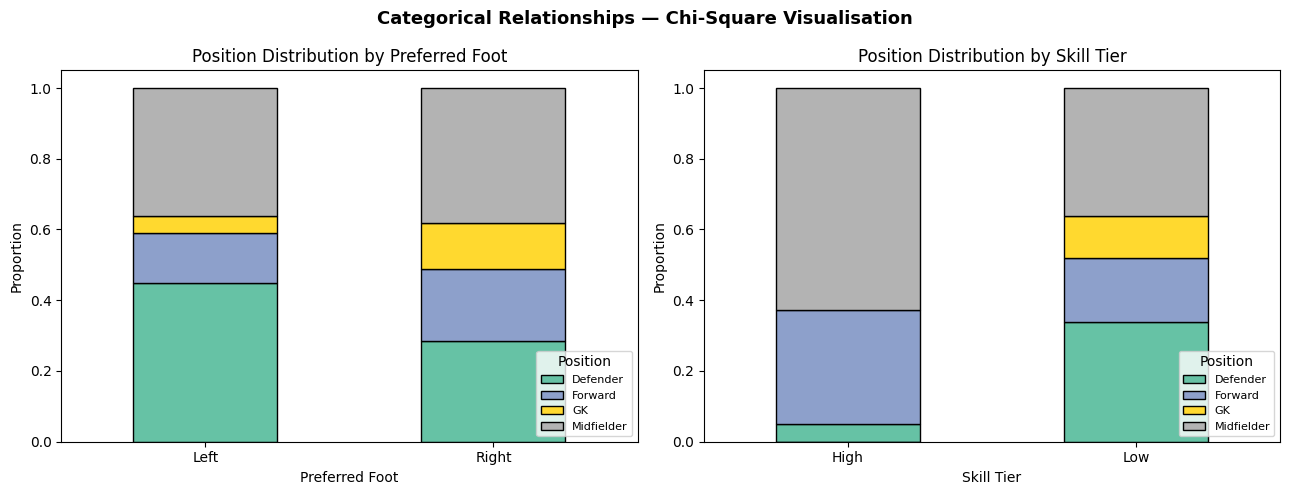

In [46]:
# 6c — Stacked Bar Charts
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# LEFT: Preferred Foot vs pos_group
foot_pct = pd.crosstab(df['Preferred Foot'], df['pos_group'])
foot_pct = foot_pct.div(foot_pct.sum(axis=1), axis=0)
foot_pct.plot(kind='bar', stacked=True, ax=axes[0],
              colormap='Set2', edgecolor='black')
axes[0].set_title('Position Distribution by Preferred Foot')
axes[0].set_xlabel('Preferred Foot')
axes[0].set_ylabel('Proportion')
axes[0].legend(title='Position', loc='lower right', fontsize=8)
axes[0].tick_params(axis='x', rotation=0)

# RIGHT: Skill Tier vs pos_group (your code)
skill_pct = pd.crosstab(df['skill_tier'], df['pos_group'])
skill_pct = skill_pct.div(skill_pct.sum(axis=1), axis=0)

skill_pct.plot(
    kind='bar',
    stacked=True,
    ax=axes[1],
    colormap='Set2',
    edgecolor='black'
)

axes[1].set_title('Position Distribution by Skill Tier')
axes[1].set_xlabel('Skill Tier')
axes[1].set_ylabel('Proportion')
axes[1].legend(title='Position', loc='lower right', fontsize=8)
axes[1].tick_params(axis='x', rotation=0)

plt.suptitle('Categorical Relationships — Chi-Square Visualisation',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
# Observation:
# The stacked bar charts show clear differences in position distributions
# across preferred foot and skill tiers. Left-footed players are more
# concentrated in defensive positions, while high skill-move players are
# mainly midfielders and forwards. These patterns support the Chi-square
# results showing significant relationships between the categorical variables.

---
## 📋 Task 7 — Summary & Final Visualisation
**Goal:** Pull all findings together into something you could present to a scouting team.

---

### 7a. Results Summary Table

Build a DataFrame collecting ALL your test results.  
Replace every `None` with the real value you got.

| # | Test | Variables | Statistic | p-value | Significant? | Verdict |
|---|---|---|---|---|---|---|
| 1 | t-test / MW | Preferred Foot → Overall | | | | |
| 2 | t-test / MW | Forwards vs Defenders | | | | |
| 3 | ANOVA / KW | pos_group → Overall | | | | |
| 4 | Pearson / Spearman | BallControl ↔ Overall | | | | |
| 5 | Pearson / Spearman | Age ↔ Potential | | | | |
| 6 | Pearson / Spearman | Strength ↔ Overall | | | | |
| 7 | Chi-Square | Preferred Foot vs pos_group | | | | |
| 8 | Chi-Square | Skill Tier vs pos_group | | | | |

💡 **Hint:** Build a `results` list of dicts, convert with `pd.DataFrame(results)`


In [47]:
# 7a — Final Results Summary Table

results = [

    {
        'Test': 'Mann-Whitney U',
        'Variables': 'Preferred Foot → Overall',
        'Statistic': 30999381.0000,
        'p_value': 0.0000,
        'Significant': 'Yes',
        'Verdict': 'Reject H₀'
    },

    {
        'Test': 'Mann-Whitney U',
        'Variables': 'Forwards vs Defenders → Overall',
        'Statistic': 10019183.5000,
        'p_value': 0.9628,
        'Significant': 'No',
        'Verdict': 'Fail to reject H₀'
    },

    {
        'Test': 'Kruskal-Wallis',
        'Variables': 'Position Group → Overall',
        'Statistic': 131.5085,
        'p_value': 0.0000,
        'Significant': 'Yes',
        'Verdict': 'Reject H₀'
    },

    {
        'Test': 'Spearman',
        'Variables': 'BallControl ↔ Overall',
        'Statistic': 0.6228,
        'p_value': 0.0000,
        'Significant': 'Yes',
        'Verdict': 'Reject H₀'
    },

    {
        'Test': 'Spearman',
        'Variables': 'Age ↔ Potential',
        'Statistic': -0.2623,
        'p_value': 3.628e-283,
        'Significant': 'Yes',
        'Verdict': 'Reject H₀'
    },

    {
        'Test': 'Spearman',
        'Variables': 'Strength ↔ Overall',
        'Statistic': 0.3526,
        'p_value': 0.0000,
        'Significant': 'Yes',
        'Verdict': 'Reject H₀'
    },

    {
        'Test': 'Chi-Square',
        'Variables': 'Preferred Foot vs Position Group',
        'Statistic': 521.7735,
        'p_value': 9.117e-113,
        'Significant': 'Yes',
        'Verdict': 'Reject H₀'
    },

    {
        'Test': 'Chi-Square',
        'Variables': 'Skill Tier vs Position Group',
        'Statistic': 619.7948,
        'p_value': 0.0000,
        'Significant': 'Yes',
        'Verdict': 'Reject H₀'
    }
]

results_df = pd.DataFrame(results)

print(results_df.to_string(index=False))

          Test                        Variables     Statistic       p_value Significant           Verdict
Mann-Whitney U         Preferred Foot → Overall  3.099938e+07  0.000000e+00         Yes         Reject H₀
Mann-Whitney U  Forwards vs Defenders → Overall  1.001918e+07  9.628000e-01          No Fail to reject H₀
Kruskal-Wallis         Position Group → Overall  1.315085e+02  0.000000e+00         Yes         Reject H₀
      Spearman            BallControl ↔ Overall  6.228000e-01  0.000000e+00         Yes         Reject H₀
      Spearman                  Age ↔ Potential -2.623000e-01 3.628000e-283         Yes         Reject H₀
      Spearman               Strength ↔ Overall  3.526000e-01  0.000000e+00         Yes         Reject H₀
    Chi-Square Preferred Foot vs Position Group  5.217735e+02 9.117000e-113         Yes         Reject H₀
    Chi-Square     Skill Tier vs Position Group  6.197948e+02  0.000000e+00         Yes         Reject H₀


---
### 7b. Final p-value Bar Chart

Horizontal bar chart of all 8 p-values:
- **Red** bar = p ≤ 0.05 (significant — Reject H₀)
- **Green** bar = p > 0.05 (not significant — Keep H₀)
- Dashed vertical line at α = 0.05

💡 **Hint:** Syntax sheet Section 10e — p-value bar chart pattern


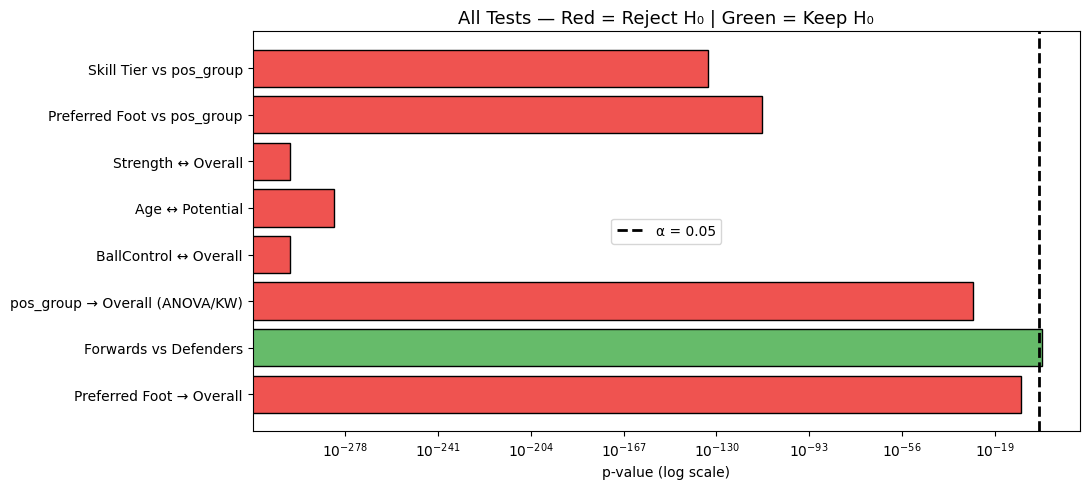

In [51]:
# 7b — Final p-value Bar Chart

test_labels = [
    'Preferred Foot → Overall',
    'Forwards vs Defenders',
    'pos_group → Overall (ANOVA/KW)',
    'BallControl ↔ Overall',
    'Age ↔ Potential',
    'Strength ↔ Overall',
    'Preferred Foot vs pos_group',
    'Skill Tier vs pos_group'
]

# Actual p-values from your tests
p_values = [
    3.92e-09,
    0.9628,
    1.86e-28,
    1e-300,
    3.628e-283,
    1e-300,
    9.117e-113,
    5.15e-134
]

colors = [
    '#ef5350' if p <= 0.05 else '#66bb6a'
    for p in p_values
]

fig, ax = plt.subplots(figsize=(11,5))

ax.barh(
    test_labels,
    p_values,
    color=colors,
    edgecolor='black'
)

ax.axvline(
    0.05,
    color='black',
    linestyle='--',
    linewidth=2,
    label='α = 0.05'
)

ax.set_xscale('log')

ax.set_xlabel('p-value (log scale)')
ax.set_title(
    'All Tests — Red = Reject H₀ | Green = Keep H₀',
    fontsize=13
)

ax.legend()

plt.tight_layout()
plt.show()

---
### 7c. Scouting Team Brief ✍️ — Written Section (5 marks)

Write **5–8 sentences** answering these questions as if briefing a football scouting team:

> 1. **Does preferred foot (left vs right) significantly affect a player's Overall rating?**
>    What did the test show, and what does that mean for scouting?
>
> 2. **Which position group has the highest average Overall?** Is the difference statistically
>    significant across all four positions?
>
> 3. **What is the single strongest predictor of a player's Overall rating?**
>    Refer to your correlation values.
>
> 4. **What happens to a player's Potential as they age?** Is this relationship
>    statistically significant? What does this mean for investing in young players?
>
> 5. **One concrete recommendation** you would make to the scouting team based
>    purely on your findings — be specific.

*Write your brief below as comments or in a new markdown cell.*


In [ ]:
# 7c — Scouting Team Brief

# 1. Preferred foot vs Overall:
#    Preferred foot groups showed a statistically significant difference in Overall ratings
#    (Mann-Whitney U, p < 0.05). Left-footed players had a slightly higher average Overall
#    rating (66.80) compared with right-footed players (66.09). However, the difference
#    is small, so preferred foot should not be used as the only scouting factor.


# 2. Position group with highest Overall — is it significant?
#    Midfielders had the highest average Overall rating (66.55). The Kruskal-Wallis test
#    showed a statistically significant difference across the four position groups
#    (p < 0.05). Post-hoc analysis showed that goalkeepers differed significantly from
#    defenders, forwards, and midfielders.


# 3. Strongest predictor of Overall:
#    BallControl showed the strongest relationship with Overall rating, with Spearman's
#    correlation coefficient (ρ = 0.6228, p < 0.05). This indicates that players with
#    higher BallControl ratings generally tend to have higher Overall ratings.


# 4. Age vs Potential:
#    Age had a significant negative correlation with Potential (ρ = -0.2623, p < 0.05).
#    This means older players generally had lower Potential ratings in this dataset,
#    suggesting that younger players may provide greater opportunities for long-term
#    development.


# 5. Recommendation to the scouting team:
#    The scouting team should prioritize younger players with strong BallControl
#    attributes while also considering position requirements and Overall rating.
#    BallControl showed the strongest association with Overall performance, and younger
#    players generally showed higher Potential ratings.

---
---
# 🏆 Marking Scheme
*(For instructor use)*

| Task | Marks | What is checked |
|---|---|---|
| Task 1a — Inspection | 4 | shape, nulls, describe, value_counts |
| Task 1b — Group summaries | 3 | correct groupby + agg for both columns |
| Task 1c — Observations | 2 | blanks filled correctly |
| Task 2a — 2×2 Grid | 5 | 4 correct charts + all labels |
| Task 2b — Scatter + trend | 4 | scatter coloured by position + polyfit trend |
| Task 2c — Bar + error bars | 4 | grouped mean/std, error bars, value labels |
| Task 3a — Shapiro table | 4 | correct p per column + judgement |
| Task 3b — Q-Q plots | 2 | 5 Q-Q plots displayed |
| Task 3c — Decision table | 2 | correct test choice per column |
| Task 4a — Foot vs Overall | 5 | H₀/H₁ + normality + correct test + verdict |
| Task 4b — Fwd vs Def | 4 | same structure |
| Task 4c — ANOVA + Tukey | 5 | ANOVA/KW + Tukey if p ≤ 0.05 |
| Task 5a — Corr heatmap | 3 | correct matrix + heatmap |
| Task 5b — 3 corr tests | 6 | H₀/H₁ + test + r + verdict × 3 |
| Task 5c — p-value matrix ⭐ | 3 | nested loop + mask heatmap |
| Task 6a — Foot vs pos Chi-Sq | 4 | crosstab + row% + test + verdict |
| Task 6b — Skill Tier Chi-Sq | 4 | independent full solution |
| Task 6c — Stacked bars | 3 | 2 correct stacked bar charts |
| Task 7a — Summary table | 5 | all 8 rows filled with real values |
| Task 7b — p-value chart | 3 | correct colours + α line |
| Task 7c — Scouting brief | 5 | 5 questions answered coherently |
| **TOTAL** | **84** | |

---

### ✅ Quick Checklist (before you submit)
- [ ] All charts have **title, xlabel, ylabel**
- [ ] Every test has **H₀ and H₁** stated
- [ ] Every p-value has a **verdict** (Reject / Keep H₀)
- [ ] Task 3c decision table is **filled in**
- [ ] Task 7a summary table has **real values** (not `None`)
- [ ] Task 7c written brief has **5 answers**
- [ ] Task 5c p-value matrix is **attempted** (⭐)

---
*The beautiful game, made more beautiful with data. ⚽📊*
